In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data set link : https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

In [2]:
df=pd.read_csv('Datasets/diabetese.csv')

In [3]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [4]:
df.shape

(100000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3854)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(96146, 9)

In [12]:
df['diabetes'].value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

<Axes: xlabel='diabetes', ylabel='count'>

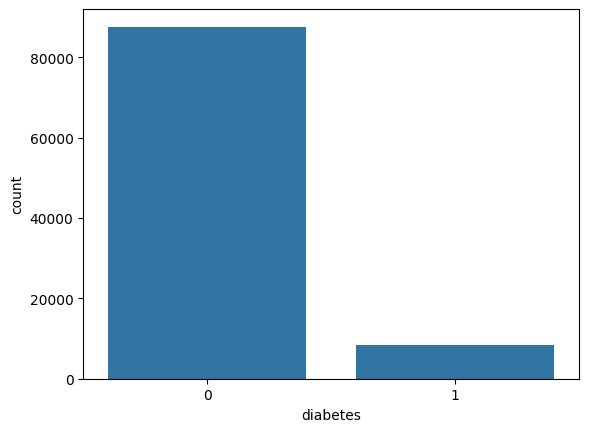

In [13]:
sns.countplot(x='diabetes', data=df)

In [14]:
df.corr(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000


<Axes: >

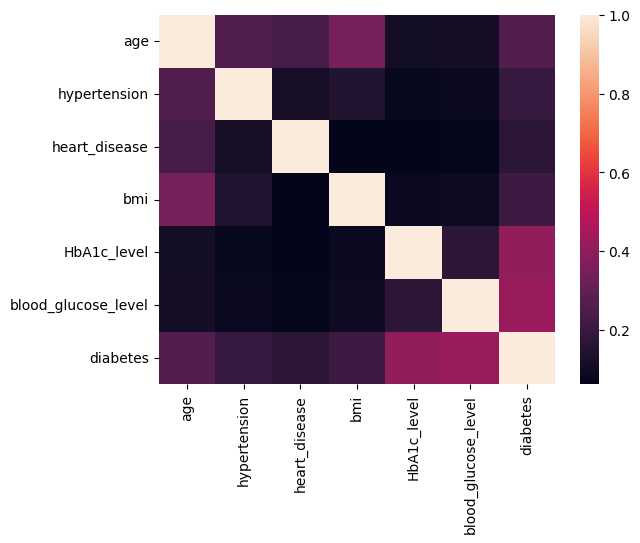

In [15]:
sns.heatmap(df.corr(numeric_only=True))

In [16]:
num_col=['age','bmi','HbA1c_level','blood_glucose_level']
cat_col=['gender','hypertension','heart_disease','smoking_history']
tar_col=['diabetes']

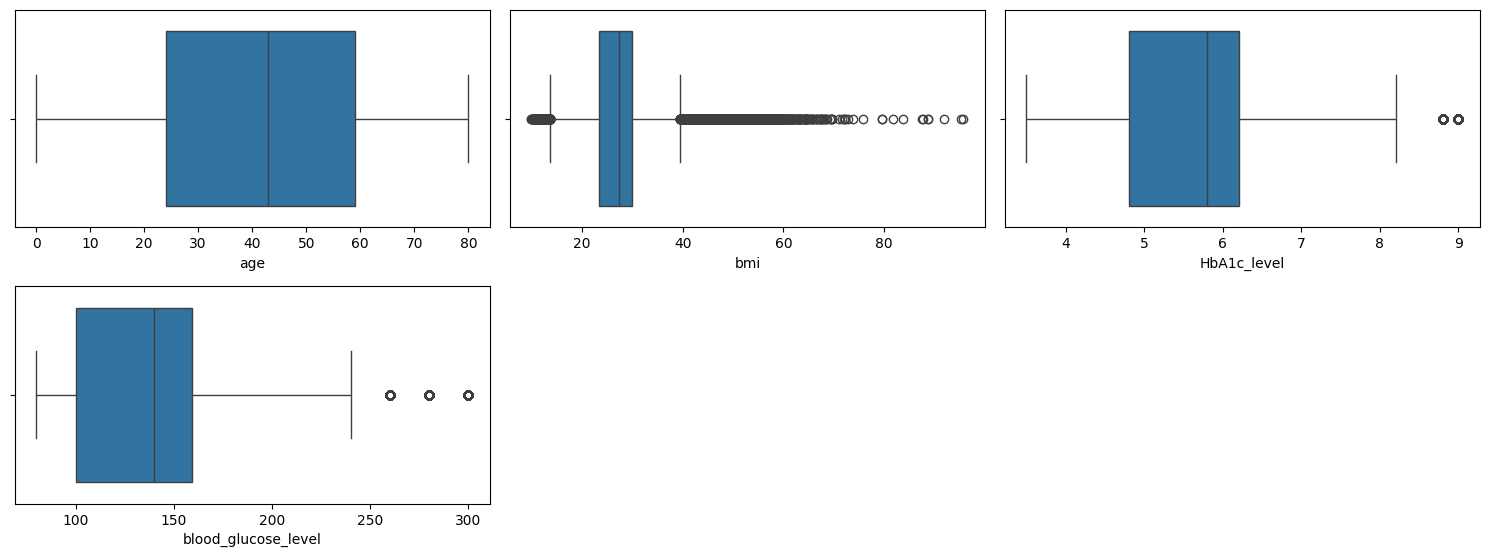

In [17]:
plt.figure(figsize=(15,8))
for i,j in enumerate(num_col,1):
    plt.subplot(3,3,i)
    sns.boxplot(data=df,x=df[j])
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns='diabetes',axis=1),
                                               df['diabetes'],
                                               test_size=0.2,
                                               random_state=42,
                                               stratify=df['diabetes'])

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

In [21]:
ctf=ColumnTransformer([
    ('ss',StandardScaler(),num_col),
    ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'),cat_col)
],remainder='passthrough')

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

In [28]:
models={
    'LogisticRegression':LogisticRegression(max_iter=5000,class_weight='balanced',random_state=42,solver='saga'),
    'DecisionTree':DecisionTreeClassifier(random_state=42),
    'RandomForest':RandomForestClassifier(n_estimators=50,n_jobs=-1,random_state=42),
    'XGBoost':XGBClassifier(random_state=42),
    'SVM':SVC(kernel='rbf',C=1.0,gamma='scale',probability=False,random_state=42)
}

In [29]:
for name,model in models.items():
    pipe=Pipeline([
        ('preprocessing',ctf),
        ('model',model)
    ])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    acc=accuracy_score(y_pred,y_test)
    cv=cross_val_score(pipe,df.drop(columns=['diabetes']),df['diabetes'],cv=5,scoring='accuracy')
    print(f'{name}')
    print(f'accuracy:{acc:.4f}')
    print(f'CV average:{cv.mean():.4f}')
    print(classification_report(y_test,y_pred))

LogisticRegression
accuracy:0.8846
CV average:0.8863
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17534
           1       0.43      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

DecisionTree
accuracy:0.9478
CV average:0.9487
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17534
           1       0.69      0.74      0.71      1696

    accuracy                           0.95     19230
   macro avg       0.83      0.85      0.84     19230
weighted avg       0.95      0.95      0.95     19230

RandomForest
accuracy:0.9693
CV average:0.9687
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                       

XGBoost is giving best results

In [30]:
pipe_xgb=Pipeline([
    ('preprocessing',ctf),
    ('XGB',XGBClassifier(random_state=42))
])

In [31]:
pipe_xgb.fit(x_train,y_train)

,steps,"[('preprocessing', ...), ('XGB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ss', ...), ('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred=pipe_xgb.predict(x_test)

In [34]:
accuracy_score(y_pred,y_test)

0.9705148205928237

In [35]:
import pickle

In [37]:
pickle.dump(pipe_xgb,open('models/diabetes.pkl','wb'))